### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

from scipy.stats import spearmanr

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
#First, list the columns in the dataset
print(data.columns)

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')


In [6]:
#Check the data types of each column
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

#The majority of the data fields are of type object and it is best to make updates but first we look at the missing values by column.


In [7]:
#Check the number of missing values in each column
missing_by_col = data.isnull().sum()
print(missing_by_col)

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64


There is a very large number of missing values for the car data field. We will also check the percentage missing for each column, to understand better the magnitude.

In [8]:
missing_pct_y_col = data.isnull().sum() / data.shape[0] * 100
print(missing_pct_y_col)

destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64


#Look for outliers, duplicated values/rows and other data issues

In [9]:
#Check for duplicate rows in the dataset

data.duplicated().any()

data.duplicated().sum()

74

In [10]:
#The data has 74 duplicate rows. Let's display them to see if they are exact duplicates or if there are any differences in the other columns.
print(f"Duplicate rows: {data.duplicated().sum()}")

if data.duplicated().sum() > 0:
    display(data[data.duplicated(keep=False)].sort_values(list(data.columns)))

Duplicate rows: 74


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
6968,Home,Alone,Snowy,30,10PM,Restaurant(20-50),2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,0,1,0
7853,Home,Alone,Snowy,30,10PM,Restaurant(20-50),2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,0,1,0
7407,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
8509,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
7406,Home,Alone,Sunny,30,6PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5606,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,below21,Single,...,less1,gt8,1~3,never,1,1,1,0,1,1
6974,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,1
7859,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,1
7414,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1


In [11]:
data_dups = data[data.duplicated()]

data_dups['coupon'].value_counts()

print(f"Duplicate rows: {data_dups.shape[0]}")
print(f"Y values in duplicates: {data_dups['Y'].value_counts().to_string()}")

Duplicate rows: 74
Y values in duplicates: Y
1    53
0    21


In [12]:
#These are the columns that have numberical values. We will check the counts of each unique value in these columns.
list_num = ['has_children', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']

for col in list_num:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()  # Blank line for readability

has_children Counts
has_children
0    7431
1    5253
Name: count, dtype: int64

toCoupon_GEQ5min Counts
toCoupon_GEQ5min
1    12684
Name: count, dtype: int64

toCoupon_GEQ15min Counts
toCoupon_GEQ15min
1    7122
0    5562
Name: count, dtype: int64

toCoupon_GEQ25min Counts
toCoupon_GEQ25min
0    11173
1     1511
Name: count, dtype: int64

direction_same Counts
direction_same
0    9960
1    2724
Name: count, dtype: int64

direction_opp Counts
direction_opp
1    9960
0    2724
Name: count, dtype: int64

Y Counts
Y
1    7210
0    5474
Name: count, dtype: int64



We notice that the data field toCoupon_GEQ5min Counts has only values of 1, meaning that all cars are at least 5 minutes away from the venue of the coupon. 
Given that all of them are one, there is no additional value and I will drop the column.
Also, direction_same and direction_opp contain the same information and we can drop one column. 

In [13]:
#These are the columns with missing values. We will convert them to categorical data type.
columns = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in columns:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()  # Blank line for readability


Bar Counts
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

CoffeeHouse Counts
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64

CarryAway Counts
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64

RestaurantLessThan20 Counts
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64

Restaurant20To50 Counts
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64



In [14]:
#Based on the counts of unique values in the columns, we will drop the columns 'car', 'toCoupon_GEQ5min', and 'direction_opp' from the dataset 
#as they have very few unique values and may not provide much information for analysis.
df = data.copy()

df = df.drop(columns=['car', 'toCoupon_GEQ5min', 'direction_opp'])

print(df.columns.tolist())

['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'has_children', 'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'Y']


1.) We make a copy of the original dataset, to be able to make changes and not affect the original. 

2.) We drop 3 data fiedls that we found unclear and not useful for our analysis. 
#We will drop the columns 'Car' (over 99% missing values), 'toCoupon_GEQ5min' (all 1), and 'direction_opp' (same information as 'direction_same') from the dataset.

3.) Second, we convert the columns with object type that contain numeric values to numeric data type
#First, we drop the duplicate rows from the dataset

#First, we convert the columns with missing values to categorical data type

There are 74 observations that look like duplicates but given that this is a result of a survey, it is possible to have the same responses. There is no ID to be able to indentify each respondent. Hence, I will not remove the duplicated rows from the dataset.  

In [15]:
#The list_num was defined earlier in the code. It contains the names of the columns that we want to convert to numeric data type, except the dropped columns. 
# We will now convert these columns to numeric data type using the apply() method and pd.to_numeric() function.

list_num = ['has_children', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'Y']

df[list_num] = df[list_num].apply(pd.to_numeric, errors="coerce")

In [16]:
for col in list_num:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()  # Blank line for readability

has_children Counts
has_children
0    7431
1    5253
Name: count, dtype: int64

toCoupon_GEQ15min Counts
toCoupon_GEQ15min
1    7122
0    5562
Name: count, dtype: int64

toCoupon_GEQ25min Counts
toCoupon_GEQ25min
0    11173
1     1511
Name: count, dtype: int64

direction_same Counts
direction_same
0    9960
1    2724
Name: count, dtype: int64

Y Counts
Y
1    7210
0    5474
Name: count, dtype: int64



In [124]:
income_order = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999",
    "$50000 - $62499",
    "$62500 - $74999",
    "$75000 - $87499",
    "$87500 - $99999",
    "$100000 or More"
]

df["income"] = pd.Categorical(
    df["income"],
    categories=income_order,
    ordered=True
)

In [125]:
df["income"].value_counts(dropna=False)

income
$25000 - $37499     1985
$12500 - $24999     1766
$100000 or More     1714
$37500 - $49999     1711
$50000 - $62499     1609
Less than $12500    1036
$62500 - $74999      840
$87500 - $99999      818
$75000 - $87499      814
Name: count, dtype: int64

In [ ]:
list_catn = ['temperature', 'time', 'age', 'education', 'occupation']

for col in list_catn:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()  # Blank line for readability

temperature Counts
temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64

time Counts
time
6PM     3230
7AM     3164
10AM    2275
2PM     2009
10PM    2006
Name: count, dtype: int64

age Counts
age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64

education Counts
education
Some college - no degree                  4351
Bachelors degree                          4335
Graduate degree (Masters or Doctorate)    1852
Associates degree                         1153
High School Graduate                       905
Some High School                            88
Name: count, dtype: int64

occupation Counts
occupation
Unemployed                                   1870
Student                                      1584
Computer & Mathematical                      1408
Sales & Related                              1093
Education&Training&Library                    943
Management     

In [18]:
for col in list_catn:
    df[col] = df[col].astype('category')

In [19]:
list_cat = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'destination', 'coupon', 'expiration', 'gender', 'maritalStatus', 'passanger', 'weather']

for col in list_cat:
    print(f"{col} Counts")
    print(data[col].value_counts(dropna=False))
    print()

Bar Counts
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64

CoffeeHouse Counts
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64

CarryAway Counts
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64

RestaurantLessThan20 Counts
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64

Restaurant20To50 Counts
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64

destination Counts
destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64

coupon Counts
coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(

In [20]:
list_cat = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'destination', 'coupon', 'expiration', 'gender', 'maritalStatus', 'passanger', 'weather']

for col in list_cat:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   destination           12684 non-null  category
 1   passanger             12684 non-null  category
 2   weather               12684 non-null  category
 3   temperature           12684 non-null  category
 4   time                  12684 non-null  category
 5   coupon                12684 non-null  category
 6   expiration            12684 non-null  category
 7   gender                12684 non-null  category
 8   age                   12684 non-null  category
 9   maritalStatus         12684 non-null  category
 10  has_children          12684 non-null  int64   
 11  education             12684 non-null  category
 12  occupation            12684 non-null  category
 13  income                12684 non-null  category
 14  Bar                   12577 non-null  category
 15  Co

In [21]:
list_unk = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in list_unk:
    df[col] = df[col].cat.add_categories('unk').fillna('unk')

In [22]:
#Check the results of the missing value imputation
columns = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in columns:
    print(f"{col} Counts")
    print(df[col].value_counts(dropna=False))
    print()

Bar Counts
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
unk       107
Name: count, dtype: int64

CoffeeHouse Counts
CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
unk       217
Name: count, dtype: int64

CarryAway Counts
CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
unk       151
Name: count, dtype: int64

RestaurantLessThan20 Counts
RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
unk       130
Name: count, dtype: int64

Restaurant20To50 Counts
Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
unk       189
Name: count, dtype: int64



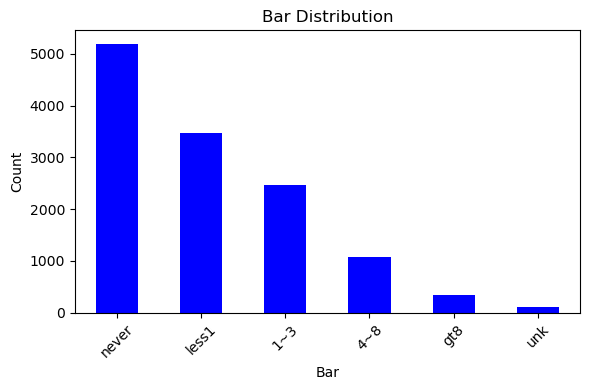

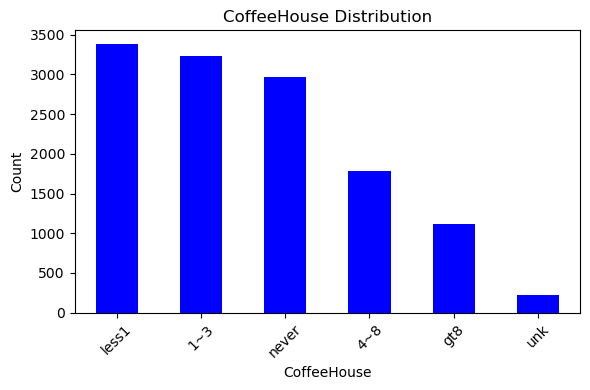

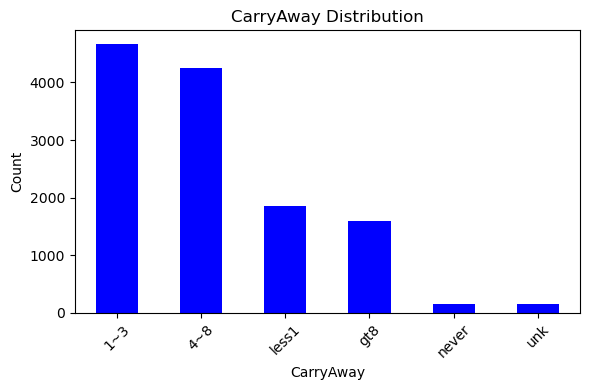

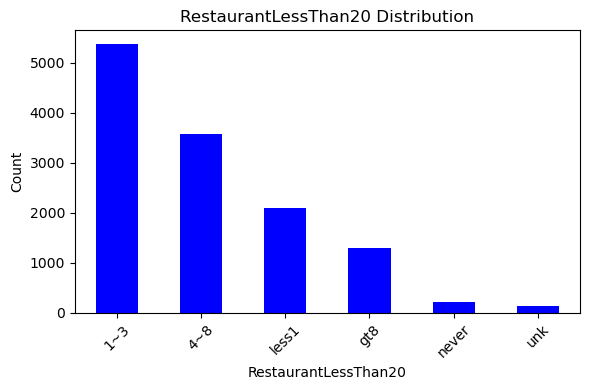

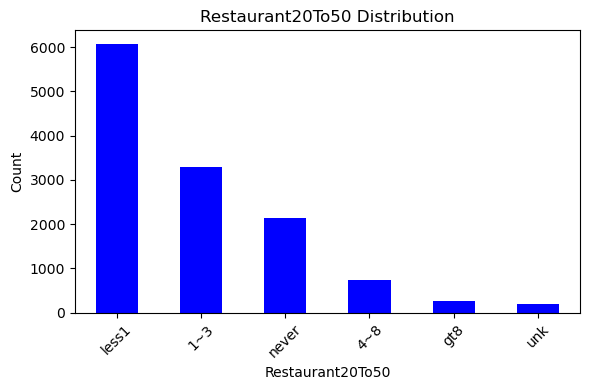

In [23]:
for col in columns:
    counts = df[col].value_counts(dropna=False)
    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='blue')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
pd.crosstab(
    df["Bar"],
    df["CoffeeHouse"],
    margins=True
)

CoffeeHouse,1~3,4~8,gt8,less1,never,unk,All
Bar,,,,,,,
1~3,569,643,259,541,440,21,2473
4~8,393,198,154,155,154,22,1076
gt8,66,66,131,44,42,0,349
less1,1036,389,218,1224,571,44,3482
never,1139,488,349,1378,1755,88,5197
unk,22,0,0,43,0,42,107
All,3225,1784,1111,3385,2962,217,12684


In [25]:
(
    df.groupby(["Bar", "CoffeeHouse", "CarryAway"])
        .size()
        .reset_index(name="Count")
)

C:\Users\khald\AppData\Local\Temp\ipykernel_35780\2917219995.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Bar", "CoffeeHouse", "CarryAway"])


,Bar,CoffeeHouse,CarryAway,Count
0,1~3,1~3,1~3,218
1,1~3,1~3,4~8,220
2,1~3,1~3,gt8,66
3,1~3,1~3,less1,65
4,1~3,1~3,never,0
...,...,...,...,...
211,unk,unk,4~8,0
212,unk,unk,gt8,0
213,unk,unk,less1,0
214,unk,unk,never,0


In [26]:
pd.crosstab(
    data["Bar"],
    data["CoffeeHouse"],
    normalize = "index"
).round(3)



CoffeeHouse,1~3,4~8,gt8,less1,never
Bar,,,,,
1~3,0.232,0.262,0.106,0.221,0.179
4~8,0.373,0.188,0.146,0.147,0.146
gt8,0.189,0.189,0.375,0.126,0.120
less1,0.301,0.113,0.063,0.356,0.166
never,0.223,0.096,0.068,0.270,0.344


In [27]:
#df_unk = df[df[columns].eq('unk').any(axis=1)]

df_unk = df.copy()


In [28]:
#There are 42 observations with "unk" in the Bar, CoffeeHouse, or CarryAway columns, at the same time. 
# We will remove these rows from the dataset and the columns that have only one instnace of missing, for instance, only Bar is missing but CoffeeHouse and CarryAway are not missing. 
# We will keep these rows in the dataset.

rows_before = len(df)

cols = ["Bar", "CoffeeHouse", "CarryAway"]
df = df[df[cols].ne("unk").all(axis=1)]

rows_after = len(df)

print(f"Removed {rows_before - rows_after} rows.")
print(f"Remaining rows: {rows_after}")

#df_test = df.query('Bar != "UNK" and CoffeeHouse != "UNK" and CarryAway != "UNK"')

Removed 391 rows.
Remaining rows: 12293


3. Decide what to do about your missing data -- drop, replace, other...

4. What proportion of the total observations chose to accept the coupon?

#Approximately 56.9% (7,210 out of 12,684) of the total observations accepted the coupon.

In [29]:
acceptance_rate = (df_unk['Y'] == 1).mean() * 100

print(f"Coupon Acceptance Rate: {acceptance_rate:.2f}%")
print(acceptance_rate)

Coupon Acceptance Rate: 56.84%
56.84326710816777


In [30]:
coupon_accept = df['Y'].value_counts() / df.shape[0] * 100

print(f"Coupon Acceptance Rate: {coupon_accept[1]:.2f}%")
print(coupon_accept)

Coupon Acceptance Rate: 56.96%
Y
1    56.959245
0    43.040755
Name: count, dtype: float64


5. Use a bar plot to visualize the `coupon` column.

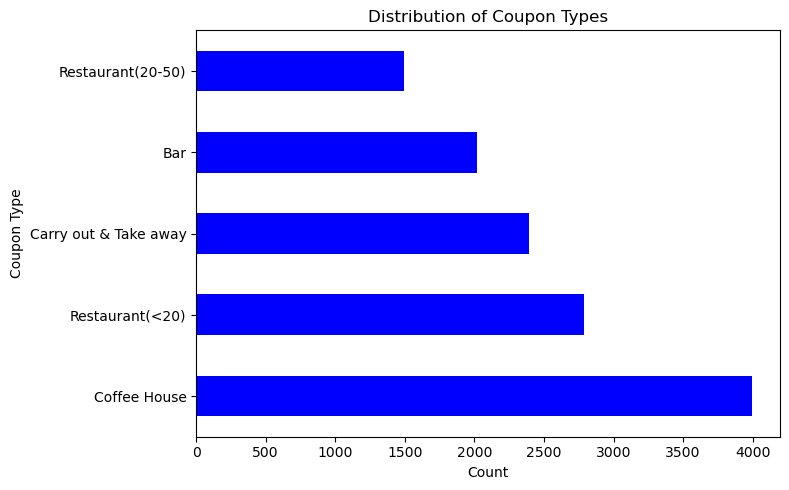

In [31]:
coupon_counts = df_unk['coupon'].value_counts()

plt.figure(figsize=(8,5))
coupon_counts.plot(kind='barh', color='blue')

plt.title('Distribution of Coupon Types')
plt.xlabel('Count')
plt.ylabel('Coupon Type')
plt.tight_layout()
plt.show()

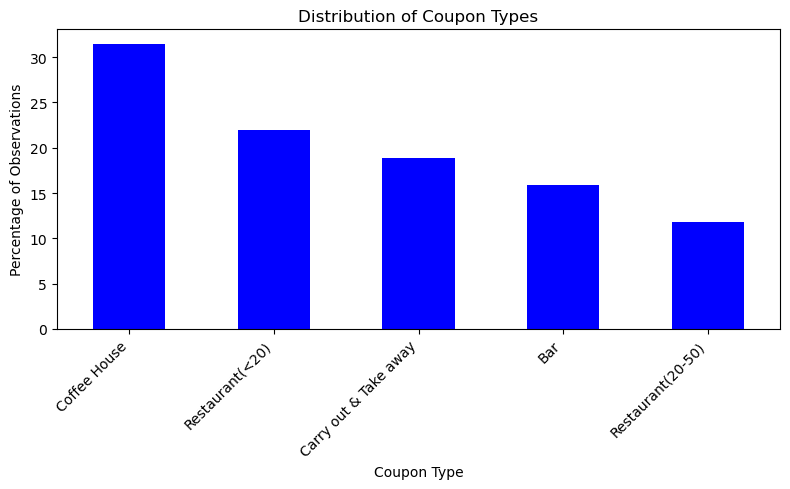

In [32]:
coupon_pct = df_unk['coupon'].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
coupon_pct.plot(kind='bar', color='blue')

plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Percentage of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Coupon Acceptance Count by Coupon Type')

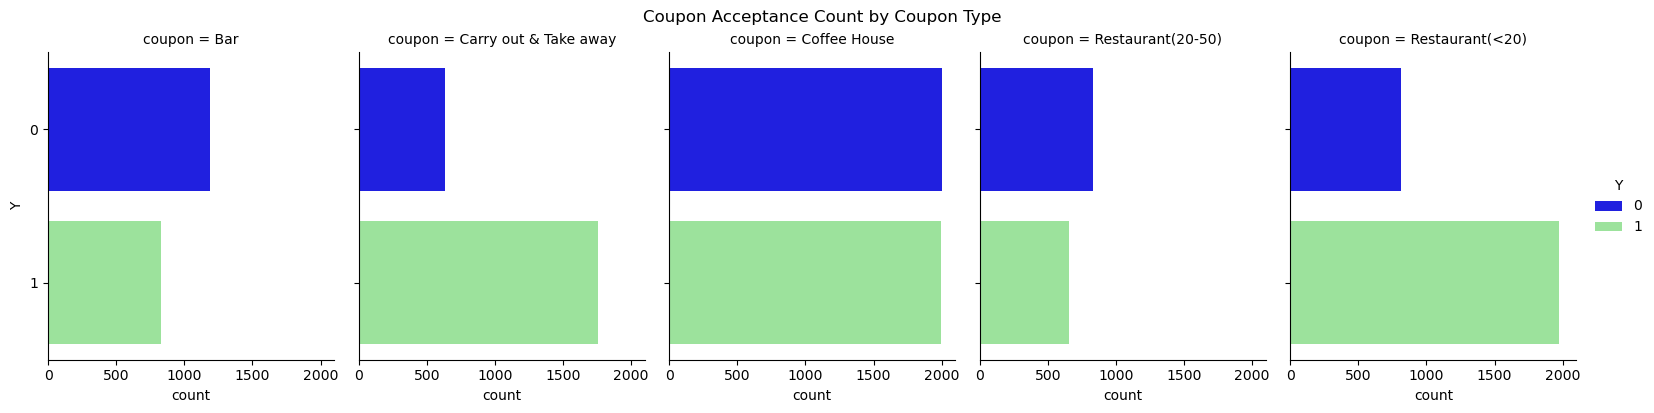

In [33]:
g = sns.catplot(
    y="Y",
    col="coupon",
    hue="Y",
    data=df_unk[df_unk['coupon'].notnull()],
    kind="count",
    height=4,
    aspect=0.8,
    palette=['blue', 'lightgreen'],
)
g.fig.suptitle('Coupon Acceptance Count by Coupon Type', y=1.02)

#col_order=['First', 'Second', 'Third']

#col_order=['First', 'Second', 'Third']

By accepted count:


Y,0,1
coupon,,
Coffee House,2001,1995
Restaurant(<20),816,1970
Carry out & Take away,633,1760
Bar,1190,827
Restaurant(20-50),834,658



By total coupon count:


Y,0,1
coupon,,
Coffee House,2001,1995
Restaurant(<20),816,1970
Carry out & Take away,633,1760
Bar,1190,827
Restaurant(20-50),834,658


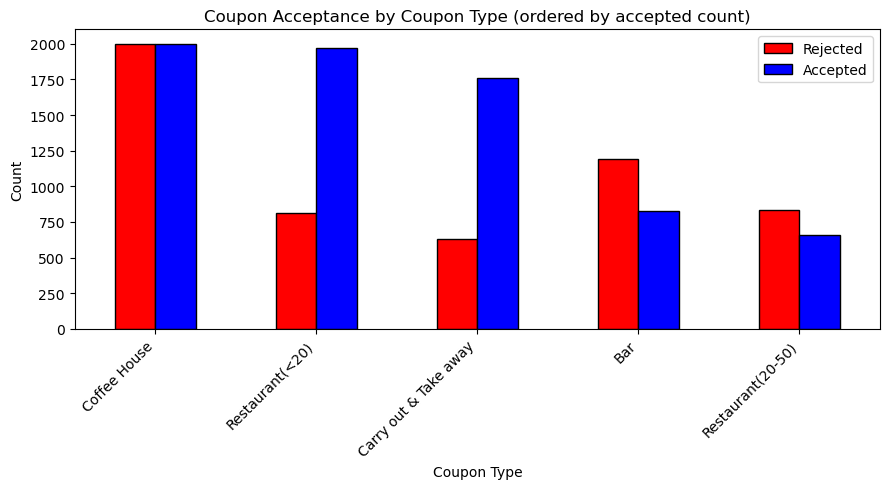

In [34]:
coupon_ct = pd.crosstab(df_unk['coupon'], df_unk['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['red', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Coupon Type (ordered by accepted count)')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

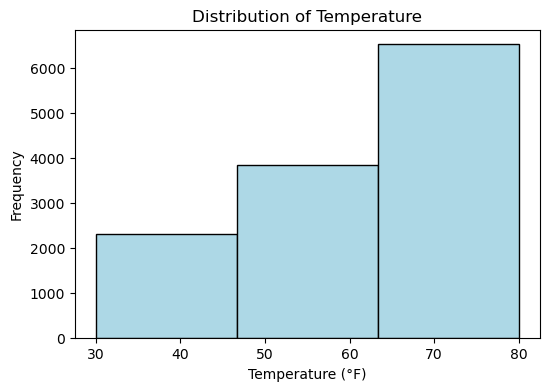

In [35]:
plt.figure(figsize=(6,4))

plt.hist(df_unk['temperature'], bins= 3, color = 'lightblue', edgecolor='black')

plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')

plt.show()

A bar plot was added below because the data field temperature has only three unique values (30°F, 55°F, and 80°F). Therefore, the histogram appears similar to a bar chart because the variable is discrete rather than continuous.

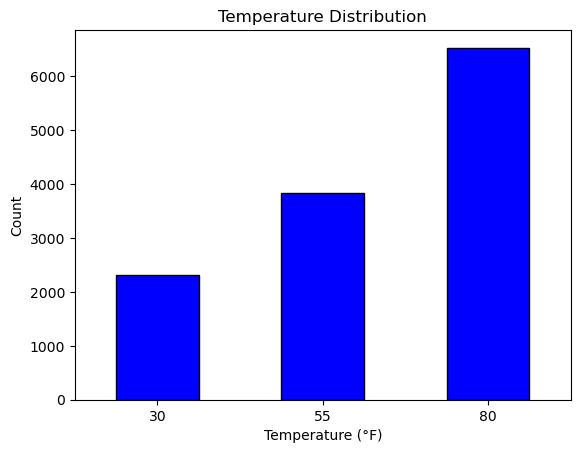

In [36]:
temp_counts = df_unk['temperature'].value_counts().sort_index()

temp_counts.plot(kind='bar', color = 'blue', edgecolor='black')

plt.title('Temperature Distribution')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

By accepted count:


Y,0,1
temperature,,
80,2609,3919
55,1779,2061
30,1086,1230



By total coupon count:


Y,0,1
temperature,,
80,2609,3919
55,1779,2061
30,1086,1230


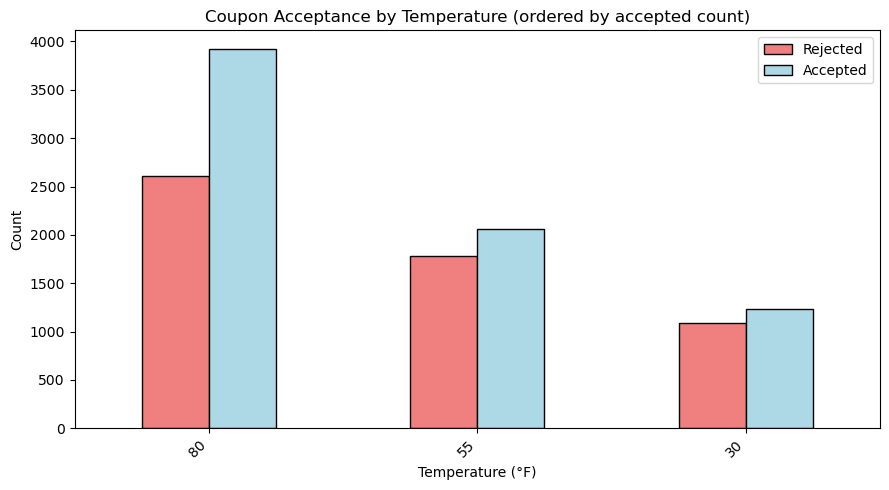

In [37]:
coupon_ct = pd.crosstab(df_unk['temperature'], df_unk['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['lightcoral', 'lightblue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Temperature (ordered by accepted count)')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [38]:
#df_bar = df_unk.query('coupon == "Bar"')

df_bar = df[df["coupon"] == "Bar"].copy()

df_bar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1951 entries, 24 to 12682
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   destination           1951 non-null   category
 1   passanger             1951 non-null   category
 2   weather               1951 non-null   category
 3   temperature           1951 non-null   category
 4   time                  1951 non-null   category
 5   coupon                1951 non-null   category
 6   expiration            1951 non-null   category
 7   gender                1951 non-null   category
 8   age                   1951 non-null   category
 9   maritalStatus         1951 non-null   category
 10  has_children          1951 non-null   int64   
 11  education             1951 non-null   category
 12  occupation            1951 non-null   category
 13  income                1951 non-null   category
 14  Bar                   1951 non-null   category
 15  CoffeeH

In [39]:
df_bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,0,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,0,0,1,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,$62500 - $74999,never,less1,4~8,4~8,less1,1,1,0,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,$12500 - $24999,never,4~8,1~3,1~3,never,0,0,0,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,$12500 - $24999,never,4~8,1~3,1~3,never,0,0,1,0


In [40]:
df_bar.value_counts(['Bar'])

df_bar.value_counts(['coupon'])


coupon               
Bar                      1951
Carry out & Take away       0
Coffee House                0
Restaurant(20-50)           0
Restaurant(<20)             0
Name: count, dtype: int64

2. What proportion of bar coupons were accepted?


In [41]:
bar_acceptance_rate = df_bar['Y'].mean()

print(f"Bar coupon acceptance rate: {bar_acceptance_rate:.1%}")

Bar coupon acceptance rate: 41.0%


In [42]:
pd.crosstab(df_bar['coupon'], df_bar['Y'])

Y,0,1
coupon,,
Bar,1151,800


3. Compare the acceptance rate between  who went to a bar 3 or fewer times a month to those who went more.


In [43]:
print(df_bar['Bar'].value_counts())

conditions = [
    df_bar['Bar'].isin(['never', 'less1', '1~3']),
    df_bar['Bar'].isin(['4~8', 'gt8'])
]

choices = ['3 or fewer', 'More than 3']

df_bar['Bar_group'] = np.select(
    conditions,
    choices,
    default='unk'
)

print("Value counts of Bar_group column in df_bar DataFrame:")
print(df_bar['Bar_group'].value_counts())


Bar
never    812
less1    559
1~3      387
4~8      147
gt8       46
unk        0
Name: count, dtype: int64
Value counts of Bar_group column in df_bar DataFrame:
Bar_group
3 or fewer     1758
More than 3     193
Name: count, dtype: int64


Drivers who visited a bar three or fewer times per month had an acceptance rate of 56.2%, compared with 62.2% among drivers who visited a bar more than three times per month. Therefore, the drivers who visit the bar mopre frequently are more likely to accept the bar coupon by 6 percentage points.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?

In [45]:
bar = ["1~3", "4~8", "gt8"]
age = ["26", "31", "36", "41", "46", "50plus"]

condition = (df_bar["Bar"].isin(bar) & df_bar["age"].isin(age))

accepted_group = df_bar.loc[condition, "Y"].mean()

other_group = df_bar.loc[~condition & df_bar["Bar"].ne("unk"), "Y"].mean()

print("Drivers who go to bars >1/month and are over 25:", round(accepted_group, 3))

print("All others:", round(other_group, 3))

Drivers who go to bars >1/month and are over 25: 0.693
All others: 0.335


In [46]:
print(data.groupby(condition)["Y"].count())

False    1544
True      407
Name: Y, dtype: int64


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.

In [47]:
#Create a column that satisfies all conditions for the target group. 
# The target group is defined as drivers who go to bars more than once a month, and had no kid as passanger and not in the farming/fishing/forestry occupation.

bar = ["1~3", "4~8", "gt8"]

df_bar["nokid_nofarm"] = (
    df_bar["Bar"].isin(bar) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["occupation"] != "Farming Fishing & Forestry")
)

#df.loc[df["Bar"] != "unk"].groupby("target_group")["Y"].mean()

compare = (df_bar.loc[df_bar["Bar"] != "unk"].groupby("nokid_nofarm")["Y"].agg(Total="count", Accepted="sum", Acceptance_Rate="mean"))

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare


,Total,Accepted,Acceptance_Rate
nokid_nofarm,,,
False,1413,419,29.65
True,538,381,70.82


In [54]:
condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["occupation"] != "Farming Fishing & Forestry")
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 70.82%
All others: 29.65%


In [49]:
bar = ["1~3", "4~8", "gt8"]

condition_nowidow = (
    df_bar["Bar"].isin(bar)
    & (df_bar["passanger"] != "Kid(s)")
    & (df_bar["maritalStatus"] != "Widowed")
)

condition_nofarm = (
    df_bar["Bar"].isin(bar)
    & (df_bar["passanger"] != "Kid(s)")
    & (df_bar["occupation"] != "Farming Fishing & Forestry")
)

print("Same classification:")
print((condition_nowidow == condition_nofarm).value_counts())

Same classification:
True    1951
Name: count, dtype: int64


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [48]:
bar = ["1~3", "4~8", "gt8"]

df_bar["nokid_nowife"] = (
    df_bar["Bar"].isin(bar) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["maritalStatus"] != "Widowed")
)

compare = (
    df_bar.loc[df_bar["Bar"] != "unk"]
    .groupby("nokid_nowife")["Y"]
    .agg(Total="count", Accepted="sum", Acceptance_Rate="mean")
)

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare




,Total,Accepted,Acceptance_Rate
nokid_nowife,,,
False,1413,419,29.65
True,538,381,70.82


In [53]:
condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["maritalStatus"] != "Widowed")
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 70.82%
All others: 29.65%


In [50]:
df_bar["under30"] = df_bar["age"].isin(["below21", "21", "26"])

condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    df_bar["under30"]
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 71.73%
All others: 34.61%


In [57]:
print (income := df_bar['income'].value_counts())
print (RestaurantLessThan20_counts := df_bar['RestaurantLessThan20'].value_counts())


income
$25000 - $37499     312
$100000 or More     288
$12500 - $24999     279
$50000 - $62499     254
$37500 - $49999     249
Less than $12500    164
$75000 - $87499     143
$87500 - $99999     133
$62500 - $74999     129
Name: count, dtype: int64
RestaurantLessThan20
1~3      857
4~8      548
less1    314
gt8      186
never     32
unk       14
Name: count, dtype: int64


In [81]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

restaurant = ["4~8", "gt8"]

income = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

condition = (
    df_bar["RestaurantLessThan20"].isin(restaurant) &
    df_bar["income"].isin(income)
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 45.65%
All others: 40.05%


In [56]:
df_bar["nokid_nofarm"].value_counts()

df_bar["nokid_nowife"].value_counts()


nokid_nowife
False    1413
True      538
Name: count, dtype: int64

In [ ]:
df_bar["nokid_nowife"].value_counts()

nokid_nowife
False    1413
True      538
Name: count, dtype: int64

In [ ]:
df_bar.columns.tolist()

['destination',
 'passanger',
 'weather',
 'temperature',
 'time',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalStatus',
 'has_children',
 'education',
 'occupation',
 'income',
 'Bar',
 'CoffeeHouse',
 'CarryAway',
 'RestaurantLessThan20',
 'Restaurant20To50',
 'toCoupon_GEQ15min',
 'toCoupon_GEQ25min',
 'direction_same',
 'Y',
 'target_group']

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

**Investigating the Coffee House Coupons**



In [127]:
#First, I will create a new `DataFrame` that contains just the Coffee House coupons.

#df_bar = df_unk.query('coupon == "Bar"')

df_coffee = df[df["coupon"] == "Coffee House"].copy()

df_coffee.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3872 entries, 23 to 12681
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   destination           3872 non-null   category
 1   passanger             3872 non-null   category
 2   weather               3872 non-null   category
 3   temperature           3872 non-null   category
 4   time                  3872 non-null   category
 5   coupon                3872 non-null   category
 6   expiration            3872 non-null   category
 7   gender                3872 non-null   category
 8   age                   3872 non-null   category
 9   maritalStatus         3872 non-null   category
 10  has_children          3872 non-null   int64   
 11  education             3872 non-null   category
 12  occupation            3872 non-null   category
 13  income                3872 non-null   category
 14  Bar                   3872 non-null   category
 15  CoffeeH

#What proportion of the Cofee House coupons were accepted?

In [128]:
coffee_acc_rate = df_coffee['Y'].mean()

print(f"Coffee House coupon acceptance rate: {coffee_acc_rate:.1%}")

Coffee House coupon acceptance rate: 49.8%


In [129]:
pd.crosstab(df_coffee['coupon'], df_coffee['Y'])

Y,0,1
coupon,,
Coffee House,1942,1930


In [130]:
df_coffee['CoffeeHouse'].value_counts().sort_index()

CoffeeHouse
1~3      1025
4~8       525
gt8       342
less1    1060
never     920
unk         0
Name: count, dtype: int64

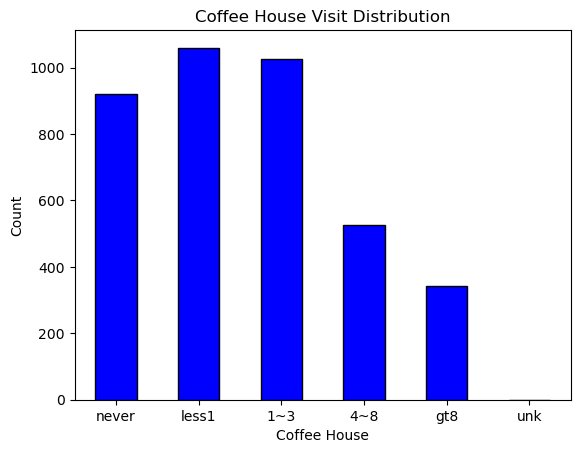

In [131]:
coffee_counts = df_coffee['CoffeeHouse'].value_counts().sort_index()

order = ['never', 'less1', '1~3', '4~8', 'gt8', 'unk']
coffee_counts = coffee_counts.reindex(order, fill_value=0)

coffee_counts.plot(kind='bar', color='blue', edgecolor='black')

plt.title('Coffee House Visit Distribution')
plt.xlabel('Coffee House')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

By accepted count:


Y,0,1
CoffeeHouse,,
1~3,359,666
less1,553,507
4~8,165,360
gt8,117,225
never,748,172



By total coupon count:


Y,0,1
CoffeeHouse,,
less1,553,507
1~3,359,666
never,748,172
4~8,165,360
gt8,117,225


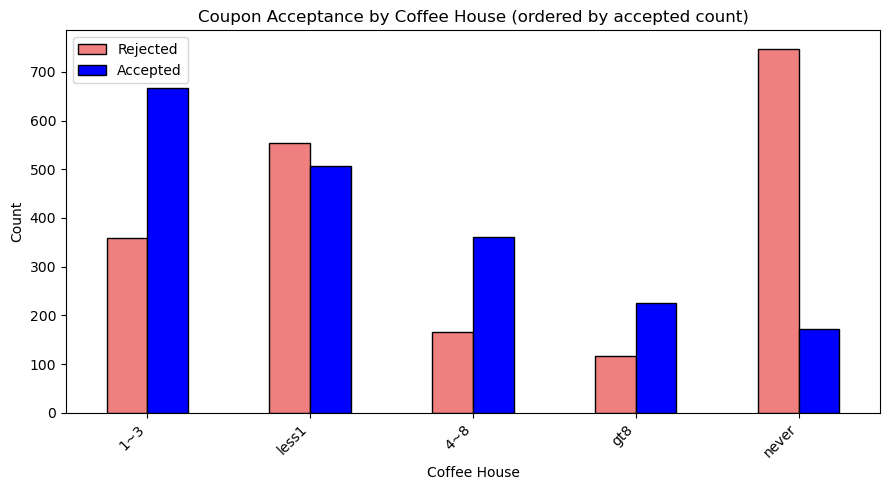

In [132]:
coupon_ct = pd.crosstab(df_coffee['CoffeeHouse'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['lightcoral', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Coffee House (ordered by accepted count)')
plt.xlabel('Coffee House')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

In [77]:
print(df_coffee['CoffeeHouse'].value_counts())

CoffeeHouse
less1    1060
1~3      1025
never     920
4~8       525
gt8       342
unk         0
Name: count, dtype: int64


3. Compare the acceptance rate between  who went to a bar 3 or fewer times a month to those who went more.
By looking at the distribution of the Coffee House visits, we can see that the majority of the observations are in the "never" and "less1" categories. 
WE will compare the acceptance rate between those who went to a Coffee House 1 or fewer times a month to those who went more.
As we can see, the drivers that go to the coffee house at least one, are twice as likely as the other group to accept the coupons

In [133]:
condition = df_coffee["CoffeeHouse"].isin(["1~3", "4~8", "gt8"])

accepted_gr = df_coffee.loc[condition, "Y"].mean()
other_gr = df_coffee.loc[~condition & (df_coffee["CoffeeHouse"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_gr:.2%}")
print(f"All others: {other_gr:.2%}")

Target group: 66.12%
All others: 34.29%


In [134]:
condition = (
    df_bar["Bar"].isin(["1~3", "4~8", "gt8"]) &
    (df_bar["passanger"] != "Kid(s)") &
    (df_bar["occupation"] != "Farming Fishing & Forestry")
)

accepted_group = df_bar.loc[condition, "Y"].mean()
other_group = df_bar.loc[~condition & (df_bar["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 70.82%
All others: 29.65%


In [ ]:
4. Compare the acceptance rate between drivers who go to a Coffee House more than once a month and are over the age of 25 to the all others.  Is there a difference?

By accepted count:


Y,0,1
age,,
21,410,452
26,389,411
31,316,296
50plus,309,223
36,203,179
41,161,156
46,107,113
below21,47,100



By total coupon count:


Y,0,1
age,,
21,410,452
26,389,411
31,316,296
50plus,309,223
36,203,179
41,161,156
46,107,113
below21,47,100


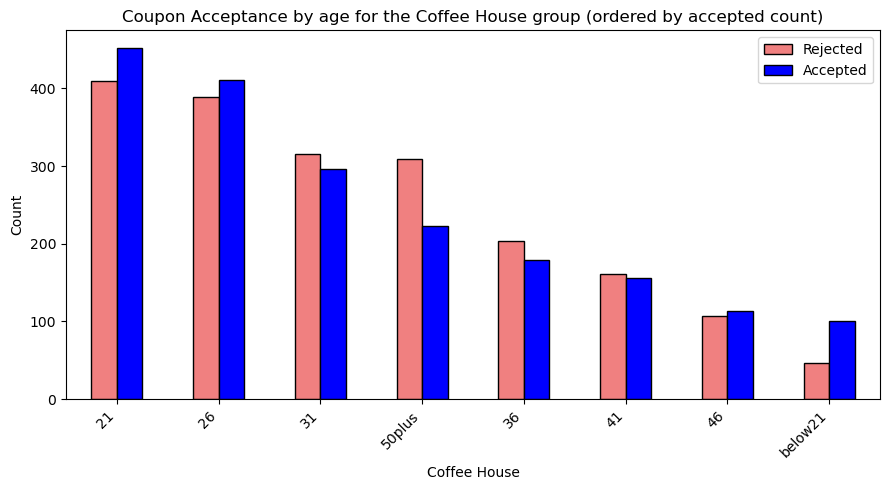

In [135]:
coupon_ct = pd.crosstab(df_coffee['age'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['lightcoral', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by age for the Coffee House group (ordered by accepted count)')
plt.xlabel('Coffee House')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

#The compare below shows that the younger drivers are more likely to accept the coupon. 

In [101]:
coffee = ["1~3", "4~8", "gt8"]

over25 = ["26", "31", "36", "41", "46", "50plus"]

condition = (
    df_coffee["CoffeeHouse"].isin(coffee) &
    df_coffee["age"].isin(over25)
)

compare = (
    df_coffee.loc[df_coffee["CoffeeHouse"] != "unk"]
    .assign(target_group=condition)
    .groupby("target_group")["Y"]
    .agg(
        Total="count",
        Accepted="sum",
        Acceptance_Rate="mean"
    )
)

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)

print(compare)

              Total  Accepted  Acceptance_Rate
target_group                                  
False          2526      1068            42.28
True           1346       862            64.04


In [ ]:
5. Occupation

By accepted count:


Y,0,1
occupation,,
Student,187,304
Unemployed,255,296
Computer & Mathematical,216,217
Sales & Related,209,139
Management,155,129
Education&Training&Library,160,120
Arts Design Entertainment Sports & Media,95,95
Office & Administrative Support,108,84
Business & Financial,75,70



By total coupon count:


Y,0,1
occupation,,
Unemployed,255,296
Student,187,304
Computer & Mathematical,216,217
Sales & Related,209,139
Management,155,129
Education&Training&Library,160,120
Office & Administrative Support,108,84
Arts Design Entertainment Sports & Media,95,95
Retired,98,66


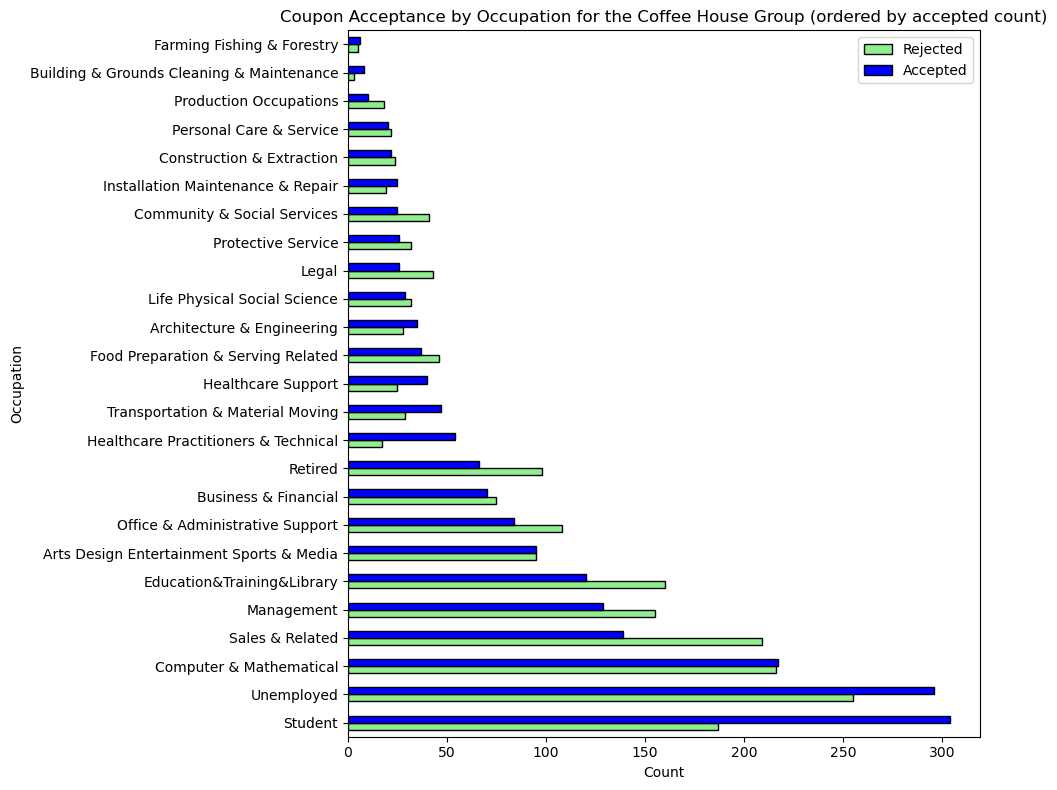

In [109]:
coupon_ct = pd.crosstab(df_coffee['occupation'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='barh',
    figsize=(10, 8),
    color=['lightgreen', 'blue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Occupation for the Coffee House Group (ordered by accepted count)')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()


In [136]:
#Create a column that satisfies all conditions for the target group. 
# The target group is defined as drivers who go to bars more than once a month, and had no kid as passanger and not in the farming/fishing/forestry occupation.

coffee = ["1~3", "4~8", "gt8"]

df_coffee["nokid_busy"] = (
    df_coffee["CoffeeHouse"].isin(coffee) &
    (df_coffee["passanger"] != "Kid(s)") &
    (~df_coffee["occupation"].isin(["Retired", "Management"]))
)

compare = (df_coffee.loc[df_coffee["nokid_busy"] == True].groupby("nokid_busy")["Y"].agg(Total="count", Accepted="sum", Acceptance_Rate="mean"))

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare

,Total,Accepted,Acceptance_Rate
nokid_busy,,,
True,1601,1068,66.71


5. #go to cheap restaurants more than 4 times a month and income is less than 50K.

In [82]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

restaurant = ["4~8", "gt8"]

income = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

condition = (
    df_coffee["RestaurantLessThan20"].isin(restaurant) &
    df_coffee["income"].isin(income)
)

accepted_group = df_coffee.loc[condition, "Y"].mean()
other_group = df_coffee.loc[~condition & (df_coffee["Bar"] != "unk"), "Y"].mean()

print(f"Target group: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

Target group: 54.70%
All others: 48.75%


Check correlation between Coffee House visits and age

In [90]:
from scipy.stats import spearmanr

coffee_map = {
    "never": 0,
    "less1": 1,
    "1~3": 2,
    "4~8": 3,
    "gt8": 4
}

age_map = {
    "below21": 0,
    "21": 1,
    "26": 2,
    "31": 3,
    "36": 4,
    "41": 5,
    "46": 6,
    "50plus": 7
}

df_corr = df_coffee.copy()

df_corr["Coffee_num"] = df_corr["CoffeeHouse"].map(coffee_map)
df_corr["Age_num"] = df_corr["age"].map(age_map)

# Remove unknowns/missing values
df_corr = df_corr.dropna(subset=["Coffee_num", "Age_num"])

corr, p = spearmanr(df_corr["Coffee_num"], df_corr["Age_num"])

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.4f}")

Spearman correlation: -0.061
p-value: 0.0000


Income_lt50k,0,1,All
CoffeeHouse,,,
1~3,480,545,1025
4~8,233,292,525
gt8,154,188,342
less1,459,601,1060
never,471,449,920
All,1797,2075,3872


6. Other tests

In [84]:
df_coffee["RestaurantLessThan20"].value_counts()


RestaurantLessThan20
1~3      1646
4~8      1092
less1     625
gt8       431
never      49
unk        29
Name: count, dtype: int64

In [85]:
df_coffee["CoffeeHouse"].value_counts()

CoffeeHouse
less1    1060
1~3      1025
never     920
4~8       525
gt8       342
unk         0
Name: count, dtype: int64

In [87]:
mapping = {
    "never": 0,
    "less1": 1,
    "1~3": 2,
    "4~8": 3,
    "gt8": 4
}

df_corr = df.copy()

df_corr["Coffee_num"] = df_corr["CoffeeHouse"].map(mapping)
df_corr["Restaurant_num"] = df_corr["RestaurantLessThan20"].map(mapping)

# Remove unknowns
df_corr = df_corr.dropna(subset=["Coffee_num", "Restaurant_num"])

In [88]:
corr, p = spearmanr(
    df_corr["Coffee_num"],
    df_corr["Restaurant_num"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.4f}")

Spearman correlation: 0.286
p-value: 0.0000


6. Compare the acceptance rates between those drivers who:

- go to Coffee House more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to Coffee House more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K, in the Coffee House group

In [151]:
#go to Coffee House more than once a month, had passengers that were not a kid, and were not widowed

coffee = ["1~3", "4~8", "gt8"]

condition = df_coffee["CoffeeHouse"].isin(["1~3", "4~8", "gt8"])

df_coffee["nokid_wife"] = (
    df_coffee["CoffeeHouse"].isin(coffee) &
    (df_coffee["passanger"] != "Kid(s)") &
    (df_coffee["maritalStatus"] != "Widowed")
)

compare = (
    df_coffee.loc[df_coffee["CoffeeHouse"] != "unk"]
    .groupby("nokid_wife")["Y"]
    .agg(Total="count", Accepted="sum", Acceptance_Rate="mean")
)

compare["Acceptance_Rate"] = (compare["Acceptance_Rate"] * 100).round(2)
compare

,Total,Accepted,Acceptance_Rate
nokid_wife,,,
False,2087,749,35.89
True,1785,1181,66.16


In [150]:
df_coffee["under30"] = df_coffee["age"].isin(["below21", "21", "26"])

condition = (
    df_coffee["CoffeeHouse"].isin(["1~3", "4~8", "gt8"]) &
    df_coffee["under30"]
)

accepted_group = df_coffee.loc[condition, "Y"].mean()
other_group = df_coffee.loc[~condition & (df_coffee["CoffeeHouse"] != "unk"), "Y"].mean()

print(f"Drivers who go to Coffee Houses >1/month and are under 30:: {accepted_group:.2%}")
print(f"All others: {other_group:.2%}")

#print("Drivers who go to Coffee Houses >1/month and are under 30:", round(accepted_group, 3))

#print("All others:", round(other_group, 3))

Drivers who go to Coffee Houses >1/month and are under 30:: 68.87%
All others: 43.51%


In [137]:
# Income < $50K
income = [
    "Less than $12500",
    "$12500 - $24999",
    "$25000 - $37499",
    "$37500 - $49999"
]

df_coffee["Income_lt50k"] = df_coffee["income"].isin(income).astype(int)

pd.crosstab(
    df_coffee["CoffeeHouse"],
    df_coffee["Income_lt50k"],
    margins=True
)

(
    pd.crosstab(
        df_coffee["CoffeeHouse"],
        df_coffee["Income_lt50k"],
        normalize="index"
    ) * 100
).round(2)

Income_lt50k,0,1
CoffeeHouse,,
1~3,46.83,53.17
4~8,44.38,55.62
gt8,45.03,54.97
less1,43.30,56.70
never,51.20,48.80


By accepted count:


Y,0,1
income,,
$12500 - $24999,256,315
$37500 - $49999,260,307
$25000 - $37499,334,299
$50000 - $62499,263,266
$100000 or More,268,260
Less than $12500,137,167
$87500 - $99999,111,130
$62500 - $74999,153,118
$75000 - $87499,160,68



By total coupon count:


Y,0,1
income,,
$25000 - $37499,334,299
$12500 - $24999,256,315
$37500 - $49999,260,307
$50000 - $62499,263,266
$100000 or More,268,260
Less than $12500,137,167
$62500 - $74999,153,118
$87500 - $99999,111,130
$75000 - $87499,160,68


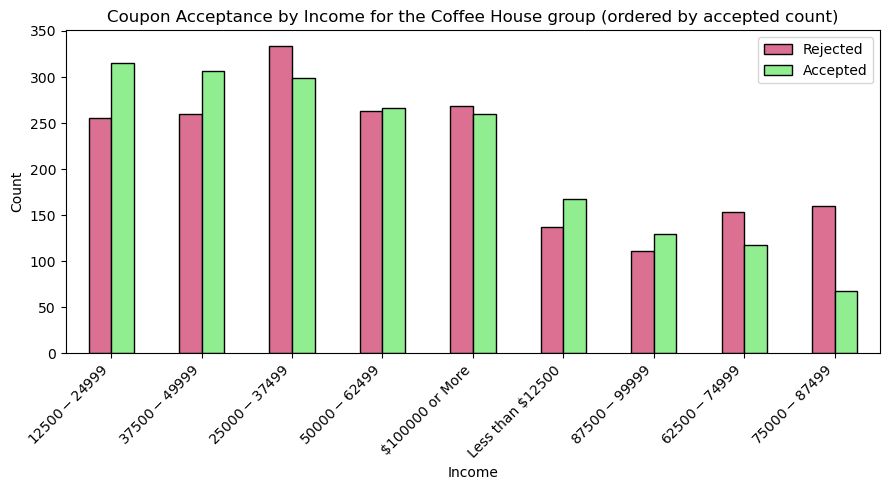

In [138]:
coupon_ct = pd.crosstab(df_coffee['income'], df_coffee['Y'])

accepted_order = coupon_ct[1].sort_values(ascending=False).index
total_order = coupon_ct.sum(axis=1).sort_values(ascending=False).index

print("By accepted count:")
display(coupon_ct.loc[accepted_order])

print("\nBy total coupon count:")
display(coupon_ct.loc[total_order])

coupon_ct.loc[accepted_order].plot(
    kind='bar',
    figsize=(9,5),
    color=['palevioletred','lightgreen'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Income for the Coffee House group (ordered by accepted count)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

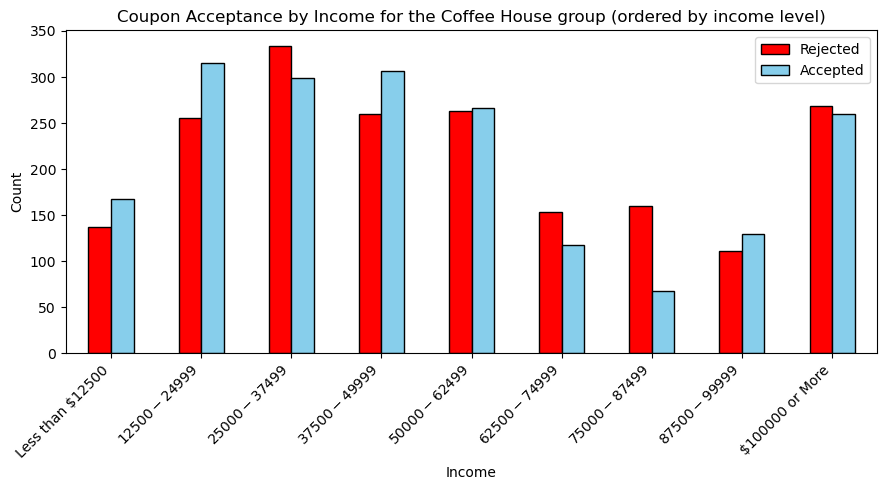

In [147]:
coupon_ct = pd.crosstab(df_coffee['income'], df_coffee['Y'])

coupon_ct[coupon_ct.columns].plot(
    kind='bar',
    figsize=(9,5),
    color=['red','skyblue'],
    edgecolor='black'
)

plt.title('Coupon Acceptance by Income for the Coffee House group (ordered by income level)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(['Rejected', 'Accepted'])
plt.tight_layout()
plt.show()

In [123]:
df["income"].value_counts()

income
$25000 - $37499     1985
$12500 - $24999     1766
$100000 or More     1714
$37500 - $49999     1711
$50000 - $62499     1609
Less than $12500    1036
$62500 - $74999      840
$87500 - $99999      818
$75000 - $87499      814
Name: count, dtype: int64

In [ ]:
#px.bar(data, x='coupon', y='Y', color='Y', title='Price by Coupon and Y')

fig = px.histogram(
    df_unk,
    x='coupon',
    color='Y',
    barmode='group',
    title='Coupon Type by Acceptance',
    labels={'coupon': 'Coupon', 'Y': 'Accepted (1) / Not Accepted (0)'}
)
fig.show()

In [ ]:
# Print rows where coupon is missing or empty
missing_coupon = data[data['coupon'].isnull() | (data['coupon'].astype(str).str.strip() == '')]
print(f"Missing coupon count: {len(missing_coupon)}")
missing_coupon
print(df_bar.isnull().sum())

In [ ]:
#data.columns = ['Coupon', 'Discount', 'Category', 'Price', 'Expiration', 'Usage']


print(data['Gender'].value_counts())




print(data.describe())


print(data['Category'].value_counts())
print(data['Discount'].value_counts())
print(data['Price'].value_counts())

print(data['Expiration'].value_counts())
print(data['Usage'].value_counts())

In [ ]:
#Automated in the section below
print("Bar Counts")
print(data['Bar'].value_counts(dropna=False))
print("CoffeeHouse Counts")
print(data['CoffeeHouse'].value_counts(dropna=False))
print("CarryAway Counts")
print(data['CarryAway'].value_counts(dropna=False))
print("RestaurantLessThan20 Counts")
print(data['RestaurantLessThan20'].value_counts(dropna=False))
print("Restaurant20To50 Counts")
print(data['Restaurant20To50'].value_counts(dropna=False))

In [ ]:
for i in columns:
    if df[column].dtype.name == 'category':
        print(f"{column} is a categorical column with {df[column].nunique()} unique values.")
    else:
        print(f"{column} is not a categorical column.")

In [ ]:
#Example from the lecture notes
#freq = pop["Entity"].value_counts()

freq_table = pop["Entity"].value_counts().reset_index()
freq_table.columns = ["Entity", "Frequency"]

print(freq_table)

freq_sort = freq_table.sort_values("Frequency")

print(freq_sort)

In [ ]:
y_coupon = data.groupby('coupon')['Y'].value_counts(normalize=True).unstack().fillna(2)

In [ ]:
#data['Bar'] = data['Bar'].fillna('unk') #This works because there are no categories in the Bar column. However, if we want to add a new category, we need to use the add_categories method.
#df['Bar'] = df['Bar'].cat.add_categories('unk').fillna('unk')

In [ ]:
px.scatter(data, x='age', y='price', color='Y', title='Age vs Price by Y')

px.scatter(gdp_pop_le.query("Year == 2017"), x = "gdp_per_capita", 
           y = "Life expectancy", color = "Entity", log_x = True)

In [ ]:
bar = ["1~3", "4~8", "gt8"]
age = ["26", "31", "36", "41", "46", "50plus"]

condition = (df_bar["Bar"].isin(bar) & df_bar["age"].isin(age))

accepted_group = df_bar.loc[condition, "Y"].mean()

other_group = df_bar.loc[~condition & df_bar["Bar"].ne("unk"), "Y"].mean()

print("Drivers who go to bars >1/month and are over 25:", round(accepted_group, 3))

print("All others:", round(other_group, 3))